Name: Fatima Timarchi

Student ID: 402105802

# Introduction to Neural Networks and Deep Learning

In this notebook, we'll explore the foundations of neural networks and deep learning. You'll learn:
- What neural networks are
- How they work mathematically
- How to implement them from scratch
- How to train them using gradient descent
- How to use deep learning libraries like PyTorch or TensorFlow

## What is a Neural Network?

A neural network is a series of algorithms that attempts to recognize relationships in a dataset through a process that mimics the way the human brain operates.

It consists of:
- Input Layer
- Hidden Layers
- Output Layer

Each layer contains neurons (or units), and each neuron computes a weighted sum of inputs followed by an activation function.

### Plot common activation functions

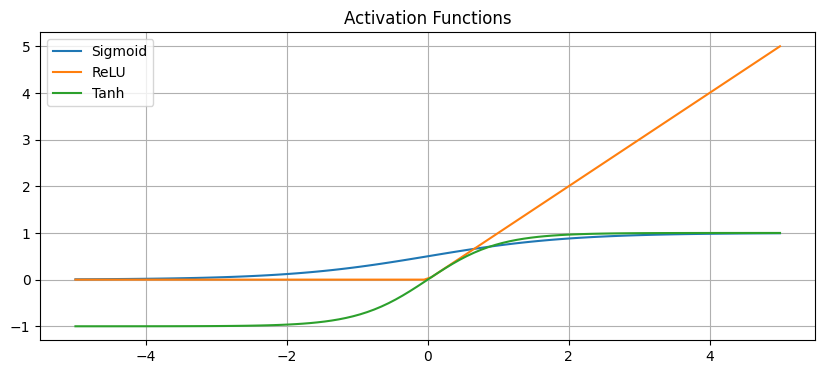

In [1]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(-5, 5, 100)
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def relu(x):
    return np.maximum(0, x)

def tanh(x):
    return np.tanh(x)


plt.figure(figsize=(10, 4))
plt.plot(x, sigmoid(x), label='Sigmoid')
plt.plot(x, relu(x), label='ReLU')
plt.plot(x, tanh(x), label='Tanh')
plt.title("Activation Functions")
plt.legend()
plt.grid(True)
plt.show()


**Question:** What are the advantages and disadvantages of using each of the following activation functions: Sigmoid, ReLU, and Tanh? In which scenarios might one be preferred over the others?

<div dir="rtl" align="right">
    sigmoid :
    
    مزایا: 
    1- خروجی آن بین صفر و یک است برای همین برای classification دودویی مناسبه
    2- خروجی آن حالت احتمالاتی دارد
    3- تابع آن نرم و پیوسته هست
    4- در همه جا مشتق پذیر است
    معایب :
    1- برای مقادیر بزرگ مثبت یا منفی ورودی گرادیان محو میشود(graidiant vanishing)
    2- خروجی ها همیشه مثبت هستند و همین باعث میشه که همگرایی در آموزش به طرز کندی اتفاق بیفتد(خروجی صفر-مرکز نیست)
    3- چون تابع نمایی هست پس از نظر محاسباتی نسبت به ReLU کند تر هست(پر هزینه است)
    موارد استفاده :
    1- معمولا در لایه خروجی برای مسائل دودویی استفاده میشه
    2- برای شبکه های کوچک یا ساده مناسب هست و برای لایه های پنهان شبکه مناسب نیست

    ReLU:
    1- ساده و سریع است
    2- مشکل محو شدن گرادیان رو تا حد خیلی خوبی کاهش میده (gradiant vanishing کم است)
    3- باعث میشه یادگیری در شبکه های عمیق سذیع تر بشه
    3- بهترین و رایج ترین انتخاب برای لایه های مخفی هست
    4- چون بسیاری از نورون ها خروجی صفر دارند پس باعث ایجاد spasity میشود
    معایب :
    1- چون یک سری نورون مرده داریم بنابراین اگه ورودی همیشه منفی باشه بنابراین گرادیان صفر میشه و دیگه یادگیری نخواهیم داشت
    2- خروجی صفر-مرکز نیست
    3- برای اون دسته از داده هایی که مقدار منفی مهم است ممکن است اطلاعات از دست بره
    موارد استفاده :
    1- لایه های مخفی در شبکه های عمیق
    2- بینایی ماشین یا همون CNN ها 
    3- اکثر معماری های مدرن یادگیری عمیق

    Tanh:
    مزایا :
    1- خروجی آن بین -1 و 1 هست بنابراین صفر-مرکز هست(zero centered)
    2- نسبت به تابع sigmoid همگراییش بهتره
    3- این تابع برای اون داده هایی که هم مقادیر مثبت دارند و هم منفی ماسب تره
    4- همواره مشتق پذیر است
    معایب :
    1- مشکل محو شدن گرادیان رو دارد (gradiant vanishing)
    2- محاسبات ان سنگین تر از ReLU هست چون محاسبات آن نمایی است
    3- در شبکه های عمیق ضعیف تر تابع ReLU عمل میکنه
    موارد استفاده :
    1- لایه های مخفی در شبکه های کم عمق
    2- در شبکه های بازگشتی یا همون RNN در بعضی از معماری های کلاسیک
    3- زمانی که برامون مهمه که خروجی صفر-مرکز هست یا نه
    
</div>

### Building a Neural Network from Scratch (NumPy)

In [2]:
import numpy as np

np.random.seed(42)

X = np.array([[0,0], [0,1], [1,0], [1,1]])
Y = np.array([[0], [1], [1], [0]])

W1 = np.random.randn(2, 4)
b1 = np.zeros((1, 4))
W2 = np.random.randn(4, 1)
b2 = np.zeros((1, 1))

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_deriv(x):
    return x * (1 - x)

lr = 0.1
for epoch in range(10001):
    Z1 = np.dot(X, W1) + b1
    A1 = sigmoid(Z1)
    Z2 = np.dot(A1, W2) + b2
    A2 = sigmoid(Z2)

    dZ2 = A2 - Y
    dW2 = np.dot(A1.T, dZ2)
    db2 = np.sum(dZ2, axis=0, keepdims=True)

    dZ1 = np.dot(dZ2, W2.T) * sigmoid_deriv(A1)
    dW1 = np.dot(X.T, dZ1)
    db1 = np.sum(dZ1, axis=0, keepdims=True)

    W1 -= lr * dW1
    b1 -= lr * db1
    W2 -= lr * dW2
    b2 -= lr * db2

    if epoch % 1000 == 0:
        loss = np.mean(np.square(A2 - Y))
        print(f"Epoch {epoch}, Loss: {loss:.4f}")


Epoch 0, Loss: 0.2832
Epoch 1000, Loss: 0.0410
Epoch 2000, Loss: 0.0007
Epoch 3000, Loss: 0.0001
Epoch 4000, Loss: 0.0000
Epoch 5000, Loss: 0.0000
Epoch 6000, Loss: 0.0000
Epoch 7000, Loss: 0.0000
Epoch 8000, Loss: 0.0000
Epoch 9000, Loss: 0.0000
Epoch 10000, Loss: 0.0000


### Test the trained network

In [3]:
print("\nTrained Weights and Biases:")
print("W1:", W1)
print("b1:", b1)
print("W2:", W2)
print("b2:", b2)

def predict(x):
    z1 = np.dot(x, W1) + b1
    a1 = sigmoid(z1)
    z2 = np.dot(a1, W2) + b2
    a2 = sigmoid(z2)
    return a2

print("\nPredictions:")
for i in range(len(X)):
    output = predict(X[i].reshape(1, -1))
    predicted = 1 if output >= 0.5 else 0
    print(f"Input: {X[i]} => Output: {output[0][0]:.4f} => Predicted: {predicted}, True: {Y[i][0]}")


Trained Weights and Biases:
W1: [[ 6.95276136  3.29872951  2.43114319  6.93655953]
 [-5.04857478 -5.97098469  3.67465562  6.6681834 ]]
b1: [[ 2.3125609  -0.91070463 -4.4602179  -2.46938027]]
W2: [[-10.40478988]
 [  8.66147075]
 [ -6.91881661]
 [ 10.78328489]]
b2: [[-1.08032279]]

Predictions:
Input: [0 0] => Output: 0.0007 => Predicted: 0, True: 0
Input: [0 1] => Output: 0.9988 => Predicted: 1, True: 1
Input: [1 0] => Output: 0.9982 => Predicted: 1, True: 1
Input: [1 1] => Output: 0.0022 => Predicted: 0, True: 0


**Question:** Why is the XOR problem not solvable by a single-layer perceptron? What changes in the network architecture make it solvable here?

<div dir="rtl" align="right">
    پاسخ بخش اول :
    
    دلیل اصلی آن این هست که داده های XOR خطی نیستند . میدانیم که یک perceptron تک لایه در اصل یک مدل خطی هست که خروجی اون توسط تابع پله ای یا sigmoid به دو کلاس تقسیم میشه و در نتیجه این مدل تنها میتونه داده های رو طبقه بندی کنه که با یک خط راست در فضای دو بعدی از هم جدا بشوند . اما توزیع داده های xor به گونه ای هست که اگه ما نمودارش رو بکشیم میبینیم که هیچ خط راستی وجود نداره که بتونه نقاط 1 رو در یک طرف و نقاط 0 رو در طرف دیگه قرار بده بنابراین perceptron تک لایه نمیتونه xor رو حل کنه

    پاسخ بخش دوم:
    باید معماری شبکه رو تبدیل به perceptron چند لایه کنیم. یک لایه پنهان (hidden layer) بین ورودی و خروجی اضافه میکنیم اینکار به شبکه اجازه میده که بتونه ویژگی های پیچیده تری رو استخراج کنه . به عبارت دیگه افزودن لایه پنهان باعث میشه که شبکه ما بتونه تبدیل های غیرخطی روی داده هاش انجام بده و درنتیجه ویژگی های غیرخطی رو هم میتونه یاد بگیره . اما باید به این دقت کنیم که اضافه کردن لایه پنهان بدون تابع activation یک کار بیهوده هست چون اضافه کردن لایه بدون activation باعث میشه شبکه در نهایت بازهم یک ترکیب خطی بشه بنابراین ما بایع از تابع های activation مانند sigmoid یا Tanh در لایه پنهانمون استفاده کنیم تا فضای ورودی به شکلی خمیده بشه و در فضای جدید بتونیم داده رو با خط یا ابر صفحه جدا کنیم. بنابراین با انجام این کار های میتونیم xor را حل کنیم
</div>

### Training with PyTorch or Keras

In [4]:
import torch
import torch.nn as nn
import torch.optim as optim

X = torch.tensor([[0.,0.],[0.,1.],[1.,0.],[1.,1.]], dtype=torch.float32)
Y = torch.tensor([[0.],[1.],[1.],[0.]], dtype=torch.float32)

learning_rate = 0.5
epochs = 50000

model = nn.Sequential(
    nn.Linear(2, 4),
    nn.Sigmoid(),
    nn.Linear(4, 1),
    nn.Sigmoid()
)

criterion = nn.MSELoss()
optimizer = optim.SGD(model.parameters(), lr=learning_rate)

for epoch in range(epochs + 1):
    output = model(X)
    loss = criterion(output, Y)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if epoch % 1000 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.4f}")

Epoch 0, Loss: 0.2501
Epoch 1000, Loss: 0.2433
Epoch 2000, Loss: 0.0878
Epoch 3000, Loss: 0.0094
Epoch 4000, Loss: 0.0037
Epoch 5000, Loss: 0.0022
Epoch 6000, Loss: 0.0015
Epoch 7000, Loss: 0.0011
Epoch 8000, Loss: 0.0009
Epoch 9000, Loss: 0.0008
Epoch 10000, Loss: 0.0006
Epoch 11000, Loss: 0.0006
Epoch 12000, Loss: 0.0005
Epoch 13000, Loss: 0.0004
Epoch 14000, Loss: 0.0004
Epoch 15000, Loss: 0.0004
Epoch 16000, Loss: 0.0003
Epoch 17000, Loss: 0.0003
Epoch 18000, Loss: 0.0003
Epoch 19000, Loss: 0.0003
Epoch 20000, Loss: 0.0002
Epoch 21000, Loss: 0.0002
Epoch 22000, Loss: 0.0002
Epoch 23000, Loss: 0.0002
Epoch 24000, Loss: 0.0002
Epoch 25000, Loss: 0.0002
Epoch 26000, Loss: 0.0002
Epoch 27000, Loss: 0.0002
Epoch 28000, Loss: 0.0002
Epoch 29000, Loss: 0.0002
Epoch 30000, Loss: 0.0002
Epoch 31000, Loss: 0.0001
Epoch 32000, Loss: 0.0001
Epoch 33000, Loss: 0.0001
Epoch 34000, Loss: 0.0001
Epoch 35000, Loss: 0.0001
Epoch 36000, Loss: 0.0001
Epoch 37000, Loss: 0.0001
Epoch 38000, Loss: 0.0001

### Test the trained network

In [5]:

print("\nTrained model parameters:")
for name, param in model.named_parameters():
    print(f"{name}: {param.data.numpy()}")

print("\nPredictions:")
with torch.no_grad():
    predictions = model(X)
    for i in range(len(X)):
        pred_val = predictions[i].item()
        pred_label = 1 if pred_val >= 0.5 else 0
        print(f"Input: {X[i].numpy()} => Output: {pred_val:.4f} => Predicted: {pred_label}, True: {int(Y[i].item())}")


Trained model parameters:
0.weight: [[-6.905128  -6.8784704]
 [ 2.4627101  2.6531255]
 [-3.9706316 -4.0498114]
 [-1.7747194 -1.2689071]]
0.bias: [ 2.9776995 -3.9933805  6.1528254  2.3152685]
2.weight: [[-12.504322   -5.6305227   7.3765354   2.338826 ]]
2.bias: [-2.1614854]

Predictions:
Input: [0. 0.] => Output: 0.0093 => Predicted: 0, True: 0
Input: [0. 1.] => Output: 0.9912 => Predicted: 1, True: 1
Input: [1. 0.] => Output: 0.9910 => Predicted: 1, True: 1
Input: [1. 1.] => Output: 0.0094 => Predicted: 0, True: 0


## Classifying Spiral Data with a Neural Network

### Generate the Spiral Dataset

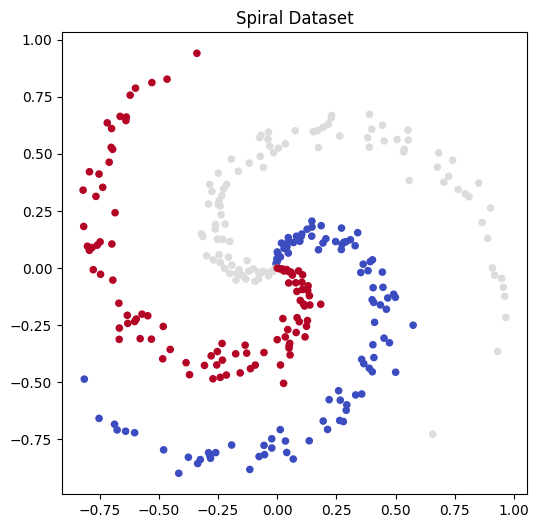

In [6]:
import numpy as np
import matplotlib.pyplot as plt

def generate_spiral(n_points=100, n_classes=3):
    X = []
    y = []
    for class_num in range(n_classes):
        ix = range(n_points * class_num, n_points * (class_num + 1))
        r = np.linspace(0.0, 1, n_points)  
        t = np.linspace(class_num * 4, (class_num + 1) * 4, n_points) + np.random.randn(n_points) * 0.2 
        X.extend(np.c_[r * np.sin(t), r * np.cos(t)])
        y.extend([class_num] * n_points)
    return np.array(X), np.array(y)

X, y = generate_spiral(n_points=100, n_classes=3)

plt.figure(figsize=(6,6))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap="coolwarm", s=20)
plt.title("Spiral Dataset")
plt.show()


### Train Neural Network with PyTorch

In [7]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split

X_tensor = torch.tensor(X, dtype=torch.float32)
y_tensor = torch.tensor(y, dtype=torch.long)

X_train, X_test, y_train, y_test = train_test_split(
    X_tensor, y_tensor, test_size=0.2, random_state=42
)

model = nn.Sequential(
    nn.Linear(X_tensor.shape[1], 64),
    nn.ReLU(),
    nn.Linear(64, 64),
    nn.ReLU(),
    nn.Linear(64, len(torch.unique(y_tensor)))
)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

for epoch in range(1000):
    y_pred = model(X_train)
    loss = criterion(y_pred, y_train)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if epoch % 100 == 0:
        with torch.no_grad():
            test_output = model(X_test)
            pred_labels = torch.argmax(test_output, dim=1)
            acc = (pred_labels == y_test).float().mean()
        print(f"Epoch {epoch}, Loss: {loss.item():.4f}, Test Accuracy: {acc.item():.2f}")

Epoch 0, Loss: 1.0972, Test Accuracy: 0.62
Epoch 100, Loss: 0.0371, Test Accuracy: 1.00
Epoch 200, Loss: 0.0220, Test Accuracy: 1.00
Epoch 300, Loss: 0.0181, Test Accuracy: 1.00
Epoch 400, Loss: 0.0164, Test Accuracy: 1.00
Epoch 500, Loss: 0.0155, Test Accuracy: 1.00
Epoch 600, Loss: 0.0149, Test Accuracy: 1.00
Epoch 700, Loss: 0.0147, Test Accuracy: 1.00
Epoch 800, Loss: 0.0145, Test Accuracy: 1.00
Epoch 900, Loss: 0.0145, Test Accuracy: 1.00


### Visualize Decision Boundary

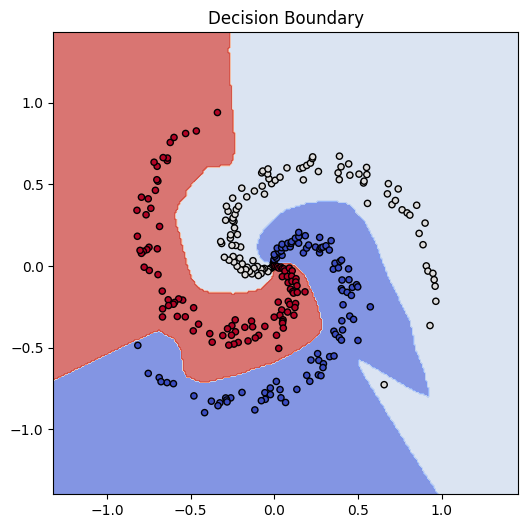

In [8]:


h = 0.01
x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
grid = torch.tensor(np.c_[xx.ravel(), yy.ravel()], dtype=torch.float32)

with torch.no_grad():
    Z = model(grid)
    Z = torch.argmax(Z, axis=1).reshape(xx.shape)

plt.figure(figsize=(6,6))
plt.contourf(xx, yy, Z, cmap="coolwarm", alpha=0.7)
plt.scatter(X[:, 0], X[:, 1], c=y, cmap="coolwarm", s=20, edgecolors='k')
plt.title("Decision Boundary")
plt.show()


<div dir="rtl" align="right">
 توضیح کد بالا:
    در این کد ما میخواستیم مرز تصمیم decision boundary مدل رو نشون بدیم در اصل مطابق شکل بالا میخواستیم ببینیم که تو هر نقطه از فضای ویژگی ها چه کلاسی رو پیشبینی میکند . حالا بخوام به صورت گام به گام بگم که چیکار کردم در ابتدا فضای ویژگی رو به یک فضای گسسته تبدیل کردم سپس به وسیله مختصات کمینه و بیشنیه داده های واقعی یک مستطیل محیطی ایجاد کردم سپس با استفاده از گام حرکت که همون h هست کل این فضا رو به هزاران نقطه ریز تقسیم کردم حالا باید رفتار مدل رو روی داده ها و همه نواحی بین اون ها بررسی کنم پس الان هر نقطه ای که دارم در اصل یک ورودی فرضی به مدل من هست  . سپس مدل آموزش دیده میاد همزمان روی تمام ورودی هاش که نقاط شبکه من هست اجرا میشه . حالا بعد از اجرا شدن خب به ما چند تا کلاس با احتمالات متفاوت میده و اونی رو انتخاب میکنه که احتمالش بیشتره .بنابراین پس از رسم شکل آن به صورت بالا مشاهده میکنیم که هر رنگ یک ناحیه از فضا هست که مدل اون رو متعلق به یک کلاس خاص میدونه و مرز تصمیم هم در اصل مرز بین رنگ ها هست . بعد از قرار دادن داده ها روی این نقشه هم مشخص میکنیم که مدل ما چطوری نقاط واقعی رو نسبت به مرز های تصمیم خودش طبقه بندی کرده و همین نشکل نشون  میده که مدل ما چه الگوی تصمیم گیری ای رو یاد گرفته . 
    
</div>

**Question:** How does the choice of optimizer (e.g., SGD vs Adam) influence training speed and final accuracy? Try both and compare.

<div dir="rtl" align="right">
    
    SDG : این optimizer در هر گام پارامتر هارو در جهت منفی گرادیان update میکنه
    سرعت : معمولا کند تر از Adam به نقطه بهینه میرسه چون به epoch های بیشتری نیاز داره
    دقت : نسبت به Adam دیرتر همگرا میشه اما به نقاط بهنیته با generalization بهتری میرسه و دقت نهایی روی داده های جدید ممکنه کمی بالاتر باشه
    تنظیمات : باید نرخ یادگیری آن را دقیق تنظیم کنیم 

    Adam : با استفاده از میانگین گیری momentum گرادیان ها میاد به صورت تطبیقی نرخ یادگیری هر پارامتر رو تنظیم میکنه
    سرعت : خیلی سریع هست . معمولا در همون epoch های ابتدایی به دقت بالایی میرسه
    دقت : خیلی سریع به خطای کم میرسه . اما در برخی موارد ممکنه در بهینه های محلی گیر کنه یا اینکه overfitting رخ بده
    تنظیمات : با مقادیر پیش فرض خیلی خوب عمل مبکنه و کمتر نیاز به تنظیم دستی داره

    در کل Adam گزینه بهتری هست چون هم سرعت بالاتری داره هم پایداری بالاتر اما SDG بیشتر برای کنترل دقیق فرایند آموزش استفاده میشه

</div>

## Deeper Classification on MNIST with Keras

### Data Loading and Basic Analysis

Train shape: (60000, 28, 28), Test shape: (10000, 28, 28)
Labels (train): [0 1 2 3 4 5 6 7 8 9]


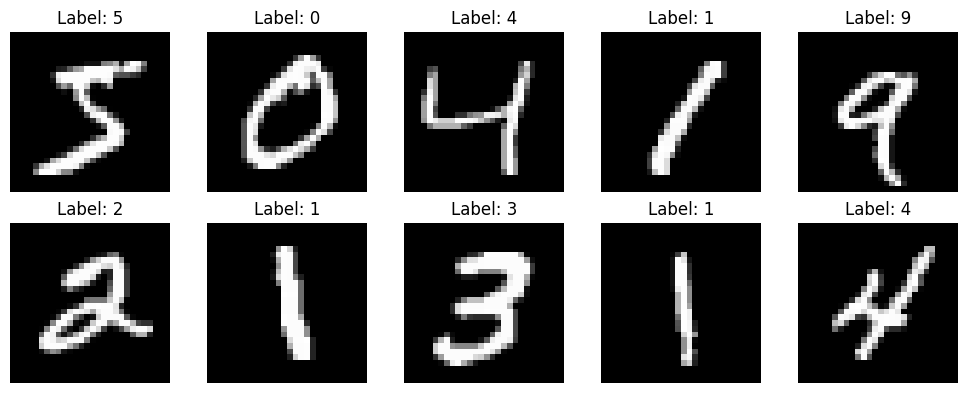

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical

(X_train, y_train), (X_test, y_test) = mnist.load_data()

X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")
print(f"Labels (train): {np.unique(y_train)}")

plt.figure(figsize=(10, 4))
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(X_train[i], cmap='gray')
    plt.title(f"Label: {y_train[i]}")
    plt.axis('off')
plt.tight_layout()
plt.show()

### Preprocessing and One-Hot Encoding

In [10]:
y_train_cat = to_categorical(y_train, num_classes=10)
y_test_cat = to_categorical(y_test, num_classes=10)

### Define a Deeper Neural Network Model

In [11]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten

model = Sequential([
    Flatten(input_shape=(28, 28)),
    Dense(256, activation='relu'),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
], name="sequential_3")

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

C:\Python313\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten (Flatten)                    │ (None, 784)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 256)                 │         200,960 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 10)                  │             650 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 242,762 (948.29 KB)

 Trainable params: 242,762 (948.29 KB)

 Non-trainable params: 0 (0.00 B)

### Train the model

In [12]:
from tensorflow.keras.datasets import mnist

(x_train, y_train), (x_test, y_test) = mnist.load_data()
x_train = x_train / 255.0
x_test = x_test / 255.0

history = model.fit(
    x_train,
    y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.1,
    verbose=1
)

Epoch 1/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - accuracy: 0.9248 - loss: 0.2503 - val_accuracy: 0.9645 - val_loss: 0.1210
Epoch 2/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.9693 - loss: 0.0986 - val_accuracy: 0.9718 - val_loss: 0.0880
Epoch 3/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.9798 - loss: 0.0650 - val_accuracy: 0.9807 - val_loss: 0.0771
Epoch 4/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.9846 - loss: 0.0471 - val_accuracy: 0.9803 - val_loss: 0.0699
Epoch 5/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.9880 - loss: 0.0375 - val_accuracy: 0.9768 - val_loss: 0.0912
Epoch 6/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.9894 - loss: 0.0319 - val_accuracy: 0.9823 - val_loss: 0.0737
Epoch 7/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.9920 - loss: 0.0250 - val_accuracy: 0.9785 - val_loss: 0.0839
Epoch 8/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.9928 - loss: 0.0223 - val_accura

### Visualize Training History

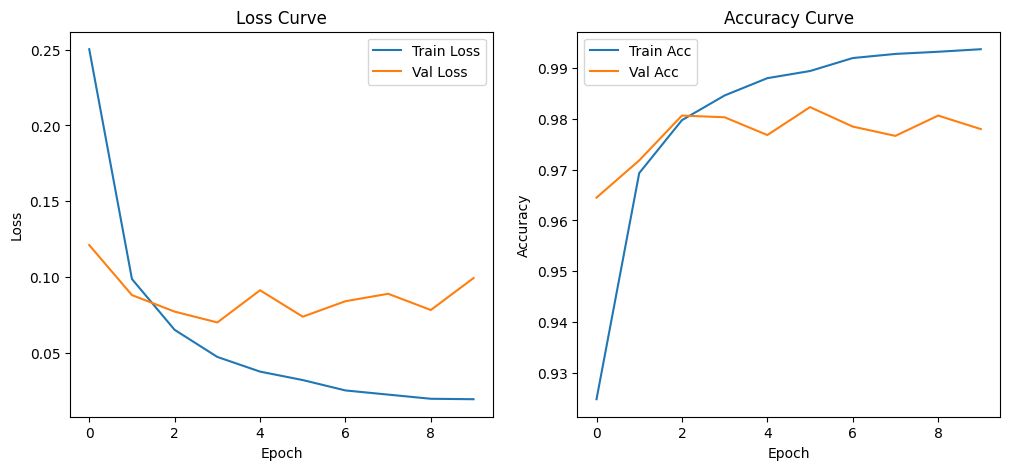

In [13]:

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')  
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title("Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title("Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

### Evaluate on test set

In [14]:

test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print(f"Test accuracy: {test_acc:.4f}")

Test accuracy: 0.9799


### Predict and visualize missclassification

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


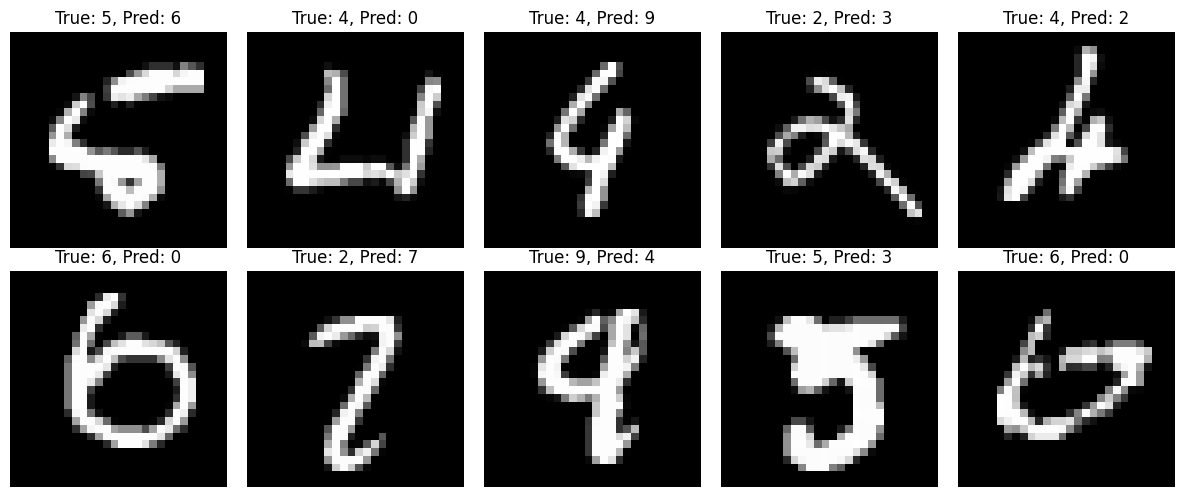

In [15]:

y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

misclassified_idxs = np.where(y_pred != y_test)[0]

plt.figure(figsize=(12, 5))
for i, idx in enumerate(misclassified_idxs[:10]):
    plt.subplot(2, 5, i+1)
    plt.imshow(X_test[idx], cmap='gray')
    plt.title(f"True: {y_test[idx]}, Pred: {y_pred[idx]}")
    plt.axis('off')
plt.tight_layout()
plt.show()

### Try with Dropout layers
Add two Dropout layers in right position and with right dropout argument

In [16]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout

model = Sequential([
    Flatten(input_shape=(28, 28)),    
    Dense(128, activation='relu'),
    Dropout(0.2),                     
    Dense(64, activation='relu'),
    Dropout(0.2),                     
    Dense(10, activation='softmax')   
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy', 
              metrics=['accuracy'])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)                  │ (None, 784)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 128)                 │         100,480 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 10)                  │             650 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

### Train the model

In [17]:

history = model.fit(
    X_train, 
    y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.2, 
    verbose=1
)

Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.8746 - loss: 0.4227 - val_accuracy: 0.9525 - val_loss: 0.1644
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9439 - loss: 0.1879 - val_accuracy: 0.9679 - val_loss: 0.1120
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9582 - loss: 0.1415 - val_accuracy: 0.9675 - val_loss: 0.1045
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9658 - loss: 0.1146 - val_accuracy: 0.9721 - val_loss: 0.0916
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.9702 - loss: 0.0979 - val_accuracy: 0.9718 - val_loss: 0.0923
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.9735 - loss: 0.0865 - val_accuracy: 0.9743 - val_loss: 0.0902
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.9755 - loss: 0.0789 - val_accuracy: 0.9708 - val_loss: 0.0986
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.9785 - loss: 0.0705 - val_accuracy: 0.

### Visualize Training History

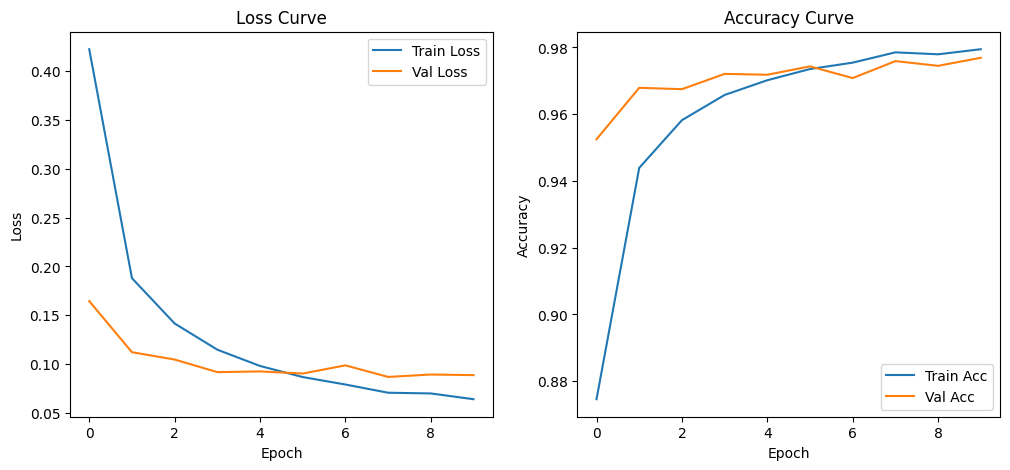

In [18]:

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title("Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title("Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

### Evaluate on test set

In [23]:

test_loss, test_acc = model.evaluate(X_test, y_test, verbose=1)

print(f"Test accuracy: {test_acc:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9789 - loss: 0.0758
Test accuracy: 0.9789


**Question:** What is the role of Dropout in this network? Compare the test accuracy. What do you observe?

<div dir="rtl" align="right">

    نقش اصلی آن برابر جلوگیری از overfitting هست . این لایه در طول آموزش در هر iteration میاد درصدی از نوزرون هارو غیر فعال میکنه تا شبکه یاد بگیره به چند تا نورون خاص وابسته نشه و مجبور بشه ویژگی های مفید رو در شبکه توزیع کنه . همچنین dropot در هر مرحله نسخه متفاوتی از معماری آموزش داده میشه و در نهایت از میانگین اون ها استفاده میشه.
    
    در مدل هایی که dropout ندارند معمولا دقت روی داده های آموزشی بسیار زیاد هست اما دقت روی داده های تست پایین تر هست . با اضافه کردن dropout این فاصله ای که گقتم کم میشه. و همون طور که مشاهده میکنید دقت تست و دقت آموزش من به هم خیلی نزدیک شده و این نشون میده که مدل من generalize شده . یعنی مدل من با dropout یاد میگریه به جای اینکه داده های آموزشی خودش رو حفظ کنه بره روی داده های تست با دقت بالا عمل کنه . و درنتیجه مدل من بهبود پیدا کرده و overfitting آن کاهش پیدا کرده .
</div>